Librerías y Funciones propias:

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..')) 

import numpy as np
import matplotlib.pyplot as plt
from helpers.room import room
from helpers.generateRirs import generateRirs

Simulation:

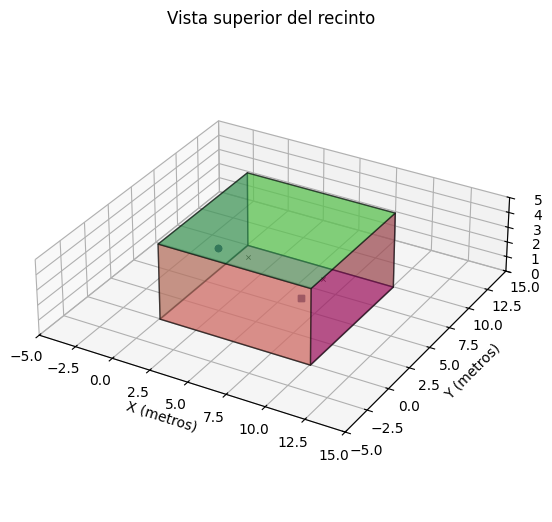

In [2]:
fs = 48000
room = room(fs)

Obtain RIRs:

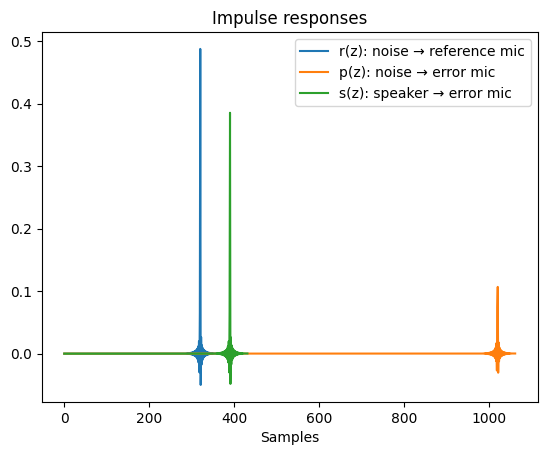

Delay R: 6.666666666666667 ms
Delay P: 21.25 ms
Delay S: 8.125 ms
In order to comply with causality, computational time must be smaller than: 6.458333333333332 ms
Reference path length:  362
Primary path length:  1062
Secondary path length:  432


In [3]:
rir_r, rir_p, rir_s = generateRirs(fs, room)

Notch FxLMS (sample by sample implementation)

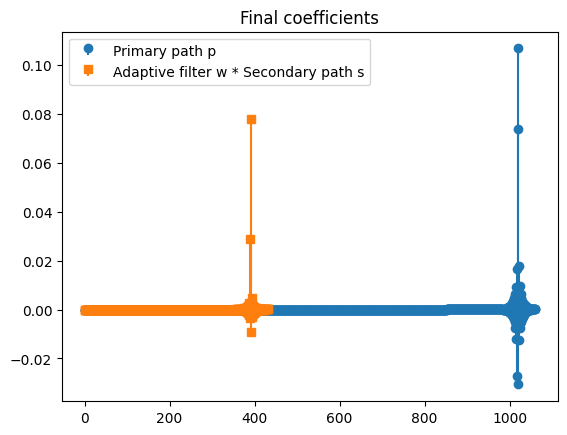

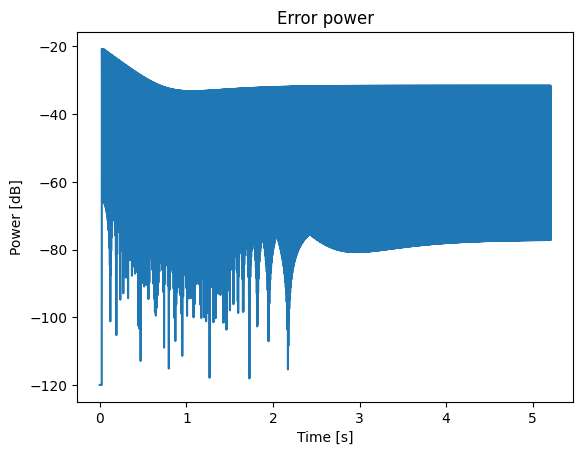

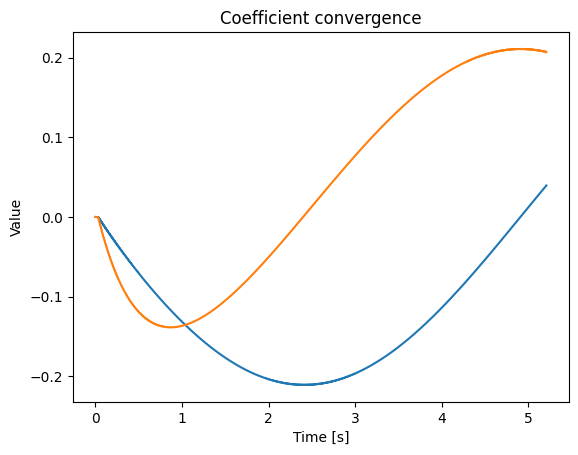

In [ ]:
np.random.seed(0)

N = 250000
t = np.arange(N) * (1/fs)

# Noise signal
noiseFrequency = 100
x = 0.64 * np.sin(2*np.pi*noiseFrequency*t)

# Control signal initialization
x1_hist = np.zeros(N)
x2_hist = np.zeros(N)
w = np.zeros(2)
noiseFrequencyError = 0 # This destroys the algorithm
controlFrequency = noiseFrequency + noiseFrequency * noiseFrequencyError
mu = 5e-4

# Primary path
p = rir_p

# Secondary path
s = rir_s

# Filtered X output initialization
f_x1_hist = np.zeros(N)
f_x2_hist = np.zeros(N)

# Adaptive filter output initilization
y_hist = np.zeros(N)

# History
e_hist = np.zeros(N)
w_hist = np.zeros((N, len(w)))

for n in range(max(len(p), len(s)), N):
    # Primary path P(z)
    x_p_vec = x[n : n - len(p) : -1]
    d = np.dot(p, x_p_vec)

    # Synthesize control signal
    x1 = np.sin(2*np.pi*controlFrequency*t[n])
    x1_hist[n] = x1
    x2 = np.cos(2*np.pi*controlFrequency*t[n])
    x2_hist[n] = x2
    y = w[0] * x1 + w[1] * x2
    y_hist[n] = y

    y_s_vec = y_hist[n : n - len(s) : -1]
    y_f = np.dot(s, y_s_vec)

    # Error signal
    e = d - y_f
    e_hist[n] = e

    # Filtered X
    x1_shat_vec = x1_hist[n : n - len(s) : -1]
    f_x1_hist[n] = np.dot(s, x1_shat_vec)


    x2_shat_vec = x2_hist[n : n - len(s) : -1]
    f_x2_hist[n] = np.dot(s, x2_shat_vec)

    # LMS algorithm
    w[0] += mu * f_x1_hist[n] * e
    w_hist[n, :] = w

    w[1] += mu * f_x2_hist[n]  *e
    w_hist[n, :] = w

plt.figure()
plt.stem(p, linefmt='C0-', markerfmt='C0o', basefmt=" ")
plt.stem(np.convolve(w, s)[:len(p)], linefmt='C1-', markerfmt='C1s', basefmt=" ")
plt.legend(['Primary path p', 'Adaptive filter w * Secondary path s'])
plt.title('Final coefficients')
plt.show()

plt.figure()
plt.plot(t, 10*np.log10(e_hist**2 + 1e-12))
plt.title('Error power')
plt.xlabel('Time [s]')
plt.ylabel('Power [dB]')
plt.show()

plt.figure()
for k in range(len(w)):
    plt.plot(t, w_hist[:, k])
plt.title('Coefficient convergence')
plt.xlabel('Time [s]')
plt.ylabel('Value')
plt.show()
